# This notebook implements batch learning for either synthetic or real data.  Notably, with a switch of commands, I can change between working with real and synthetic data.

In [1]:
# Import packages
import numpy as np
from sklearn.gaussian_process.kernels import Matern, ConstantKernel
from scipy.linalg import cholesky, solve_triangular, det
import torch
from torch.autograd import Function
from torch.linalg import cholesky, solve_triangular
import torch.optim as optim
import matplotlib.pyplot as plt
import scanpy as sc
import numpy as np
import pandas as pd
import sys
import random
from scipy.special import kv, kvp, gamma
from scipy.special import beta as B
from scipy.spatial.distance import pdist, squareform
from scipy.stats import multivariate_normal
from sklearn.gaussian_process.kernels import Matern, ConstantKernel
from scipy.interpolate import griddata
from scipy.linalg import cho_solve, cho_factor
from scipy.optimize import minimize

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [2]:
# # Global parameters:
number_of_cycles = 500 # how many passes through the training data we go through
number_of_groups = 1 # divide the data set into smaller ones, to make fitting easier.
locations_per_group = 200 # how many locations to observe per group
number_of_locations = number_of_groups * locations_per_group # total locations
number_of_simulations = 50 # for synthetic data, how many optimisation to average over
steps_per_batch = 5
dims = 2  # 2D spatial
p =  3 # how many features 

In [3]:
def isolate_gene_values (adata, gene_name):
    gene_values = pd.DataFrame(adata[:, gene_name].X.toarray(), columns=[gene_name], index=adata.obs_names)
    return gene_values

def load_real_data(head=15000):
    # Load the H5AD file
    adata = sc.read_h5ad('ovary_Puck_230517_39.h5ad')
    coordinates = pd.DataFrame(adata.obsm["spatial"], columns=['x', 'y'], index=adata.obs_names)
    df = pd.concat([
        coordinates,
        isolate_gene_values(adata, "Serpine2"),
        isolate_gene_values(adata, "Tagln"),
        isolate_gene_values(adata, "Acta2"),
        isolate_gene_values(adata, "Mgp"),
        isolate_gene_values(adata, "S100a6"),
        isolate_gene_values(adata, "Col1a2"),
        isolate_gene_values(adata, "Nr5a2"),
        isolate_gene_values(adata, "Inhba"),
        isolate_gene_values(adata, "Tpm2"),
        isolate_gene_values(adata, "Tdrd5")
    ], axis=1)
    df = df.sample(frac=1)
    df = df.head(head)
    
    df['x'] = df['x'] / df['x'].median()
    df['y'] = df['y'] / df['y'].median()
    
    # Normalize all gene columns by dividing by 1000
    genes_to_include = ["Serpine2", "Tagln", "Acta2", "Mgp", "S100a6", "Col1a2", "Nr5a2", "Inhba", "Tpm2", "Tdrd5"]
    for gene in genes_to_include:
        df[gene] = df[gene] / 1000
    X = torch.tensor(df[['x', 'y']].values, dtype=torch.float64)

    # List of gene columns
    genes_to_include = ["Serpine2", "Tagln", "Acta2", "Mgp", "S100a6", "Col1a2", "Nr5a2", "Inhba", "Tpm2", "Tdrd5"]
    # Convert the gene columns into a tensor
    Y = torch.tensor(df[genes_to_include].values, dtype=torch.float64)
    return X,Y

# Produce p plots so that I can visualise how these data look like
def plot_gp_data(X, Y):
    """
    Plots the p-variate data for each variable.
    
    Parameters:
    - X (torch.Tensor): The matrix of locations of shape (n_locations, dimensions).
    - Y (torch.Tensor): The simulated dataset of shape (n_locations, p).
    """
    p = Y.size(1)
    
    # Create a plot for each variable
    for i in range(p):
        plt.figure(figsize=(8, 6))
        if X.size(1) == 2:  # 2D locations
            plt.scatter(X[:, 0].detach().numpy(), X[:, 1].detach().numpy(), c=Y[:, i].detach().numpy(), cmap='viridis', s=1)
            plt.colorbar(label=f'Variable {i+1}')
            plt.xlabel('X1')
            plt.ylabel('X2')
        elif X.size(1) == 1:  # 1D locations
            plt.plot(X.detach().numpy(), Y[:, i].detach().numpy(), '-o')
            plt.xlabel('X')
            plt.ylabel(f'Variable {i+1}')
        
        plt.title(f'Visualization of Variable {i+1}')
        plt.tight_layout()
        plt.show()

    return True

def is_positive_definite(matrix):
    """Check if a matrix is positive definite."""
    try:
        torch.linalg.cholesky(matrix)
        return True
    except RuntimeError:
        return False

# Define the custom autograd function for the Bessel function of the second kind
class BesselKFunction(torch.autograd.Function):
    @staticmethod
    def forward(ctx, v, x):
        # Store v and x for the backward pass
        ctx.save_for_backward(v, x)
        
        # Convert tensors to numpy for SciPy compatibility
        x_np = x.detach().cpu().numpy()
        v_np = v.detach().cpu().numpy()
        
        # Compute the Bessel function using SciPy
        output = torch.tensor(kv(v_np, x_np), dtype=torch.float64)
        
        # Return the output as a tensor
        return output.to(x.device)

    @staticmethod
    def backward(ctx, grad_output):
        # Retrieve saved tensors
        v, x = ctx.saved_tensors
        
        # Convert tensors to numpy for gradient calculations
        x_np = x.detach().cpu().numpy()
        v_np = v.detach().cpu().numpy()
        
        # Numerical derivative with respect to x
        epsilon_x = 1e-7
        grad_x = (kv(v_np, x_np + epsilon_x) - kv(v_np, x_np - epsilon_x)) / (2 * epsilon_x)
        grad_x = torch.tensor(grad_x, dtype=torch.float64).to(x.device)
        
        # Derivative with respect to v (using kvp, which gives the derivative of kv with respect to v)
        grad_v = torch.tensor(kvp(v_np, x_np), dtype=torch.float64).to(v.device)
        
        # Multiply by the incoming gradient (chain rule)
        grad_input_x = grad_output * grad_x
        grad_input_v = grad_output * grad_v
        
        return grad_input_v, grad_input_x

def matern_kernel(pairwise_distances, nu, length_scale, sigma2, epsilon=1e-6):
    """
    Computes the Matérn covariance matrix with support for broadcasting over nu, length_scale, and sigma2.

    Parameters:
    - pairwise_distances (torch.Tensor): Pairwise distances, shape (n_locations, n_locations) or broadcasted to (p, p, n_locations, n_locations).
    - nu (torch.Tensor): Smoothness parameter, can be broadcasted (e.g., shape (p, p, 1, 1)).
    - length_scale (torch.Tensor): Length scale parameter, can be broadcasted (e.g., shape (p, p, 1, 1)).
    - sigma2 (torch.Tensor): Variance parameter, can be broadcasted (e.g., shape (p, p, 1, 1)).
    - epsilon (float): A small perturbation to ensure nu != 0.5.

    Returns:
    - covariance_matrix (torch.Tensor): The computed Matérn covariance matrix, with shape depending on input broadcasting.
    """

    # Add a tiny perturbation to nu if it's exactly 0.5
    nu = torch.where(nu == 0.5, nu + epsilon, nu)

    # Compute the scaled distances using broadcasting
    scaled_distances = torch.sqrt(2 * nu) * (pairwise_distances / length_scale)
    
    # Clamp the values of scaled_distances to avoid extreme numbers
    scaled_distances = torch.clamp(scaled_distances, min=1e-9, max=1e6)

    # Use the custom Bessel function with autograd
    bessel_term = BesselKFunction.apply(nu, scaled_distances)
    scaling_term = (2 ** (1.0 - nu)) / torch.exp(torch.lgamma(nu))
    covariance_matrix = sigma2 * scaling_term * (scaled_distances ** nu) * bessel_term
    
    # Set diagonal elements where pairwise_distances == 0 to sigma2
    covariance_matrix = torch.where(pairwise_distances == 0, sigma2, covariance_matrix)
    
    return covariance_matrix

# Now that we have the alpha, nu, and sigma matrices, we want to define a function 
# Input are those three matrices, as well as X, the matrix of locations
# Output is the matern covariance matrix, computed by the function 
# matern_kernel(pairwise_distances, nu, length_scale, sigma2)
def compute_matern_covariance(alpha_matrix, nu_matrix, sigma_matrix, X):
    """
    Computes the Matérn covariance matrix using the provided alpha, nu, and sigma matrices.

    Parameters:
    - alpha_matrix (torch.Tensor): The alpha matrix of shape (p, p).
    - nu_matrix (torch.Tensor): The nu matrix of shape (p, p).
    - sigma_matrix (torch.Tensor): The sigma matrix of shape (p, p).
    - X (torch.Tensor): The matrix of locations of shape (n_locations, dimensions).

    Returns:
    - K (torch.Tensor): The Matérn covariance matrix of shape (n_locations * p, n_locations * p).
    """
    n_locations = X.size(0)
    p = alpha_matrix.size(0)

    # Compute pairwise distances between locations (n_locations, n_locations)
    pairwise_distances = torch.cdist(X, X)
    
    # Expand pairwise distances to (p, p, n_locations, n_locations) for broadcasting
    pairwise_distances_expanded = pairwise_distances.unsqueeze(0).unsqueeze(0).expand(p, p, n_locations, n_locations)
    
    # Ensure the correct shapes for broadcasting
    nu_expanded = nu_matrix.unsqueeze(-1).unsqueeze(-1)  # Shape: (p, p, 1, 1)
    alpha_expanded = alpha_matrix.unsqueeze(-1).unsqueeze(-1)  # Shape: (p, p, 1, 1)
    sigma_expanded = sigma_matrix.unsqueeze(-1).unsqueeze(-1)  # Shape: (p, p, 1, 1)

    # Compute the covariance matrix using broadcasting
    K_blocks = matern_kernel(
        pairwise_distances_expanded, 
        nu_expanded,  
        alpha_expanded,  
        sigma_expanded
    )
    
    # Reshape to create the block covariance matrix (n_locations * p, n_locations * p)
    K = K_blocks.permute(0, 2, 1, 3).reshape(p * n_locations, p * n_locations)
    
    return K
    
def compute_parameter_matrices(Delta_A, Delta_B, rho_A, rho_B, rho_V, W, alpha, nu, sigma):
    """
    Computes p by p matrices alpha, nu, and sigma based on the provided parameters.

    Parameters:
    - Delta_A, Delta_B, rho_A, rho_B, rho_V (torch.float64): Scalars.
    - W, alpha, nu, sigma (torch.float64): 1D tensors of size p.

    Returns:
    - alpha_matrix, nu_matrix, sigma_matrix: p x p matrices of computed values.
    """
    p = W.size(0)
    dim = 2  # Given constant value

    # Calculate alpha_ij matrix
    alpha_i_squared = alpha.unsqueeze(1)**2  # shape: (p, 1)
    alpha_j_squared = alpha.unsqueeze(0)**2  # shape: (1, p)
    alpha_matrix = torch.sqrt((alpha_i_squared + alpha_j_squared) / 2 + Delta_B * (1 - rho_B))
    
    # Calculate nu_ij matrix
    nu_matrix = (nu.unsqueeze(1) + nu.unsqueeze(0)) / 2 + Delta_A * (1 - rho_A)
    
    # Calculate sigma_ij matrix
    W_i = W.unsqueeze(1)  # shape: (p, 1)
    W_j = W.unsqueeze(0)  # shape: (1, p)
    sigma_matrix = (
        W_i * W_j * rho_V * alpha_matrix ** (-2 * Delta_A - (nu.unsqueeze(0) + nu.unsqueeze(1))) *
        torch.exp(
            torch.lgamma((nu.unsqueeze(0) + nu.unsqueeze(1)) / 2 + dim / 2) +
            torch.lgamma(nu_matrix) -
            torch.lgamma(nu_matrix + dim / 2)
        )
    )    
     
    # Set diagonal entries for alpha_matrix
    
    
    # Set diagonal entries for alpha_matrix with grad tracking
    alpha_matrix = alpha_matrix + torch.diag(alpha - torch.diag(alpha_matrix))
    # Set diagonal entries for nu_matrix with grad tracking
    nu_matrix = nu_matrix + torch.diag(nu - torch.diag(nu_matrix))
    # Set diagonal entries for sigma_matrix with grad tracking
    sigma_matrix = sigma_matrix + torch.diag(sigma - torch.diag(sigma_matrix))

    return alpha_matrix, nu_matrix, sigma_matrix

# Example usage
# Delta_A = torch.tensor(0.5, dtype=torch.float64, requires_grad=True)
# Delta_B = torch.tensor(0.5, dtype=torch.float64, requires_grad=True)
# rho_A = torch.tensor(0.5, dtype=torch.float64, requires_grad=True)
# rho_B = torch.tensor(0.5, dtype=torch.float64, requires_grad=True)
# rho_V = torch.tensor(0.8, dtype=torch.float64, requires_grad=True)


# W = torch.tensor([1.0, 2.0, 3.0], dtype=torch.float64, requires_grad=True)
# alpha = torch.tensor([0.2, 0.3, 0.4], dtype=torch.float64, requires_grad=True)
# nu = torch.tensor([0.5, 0.6, 0.7], dtype=torch.float64, requires_grad=True)
# sigma = torch.tensor([0.1, 0.2 , 0.3], dtype=torch.float64, requires_grad=True)

def random_search_parameters(p, X, max_iterations=100000):
    """
    Randomly searches for a combination of parameters that satisfies a given clause.
    
    Parameters:
    - p (int): The length of the list W (number of parameters W1 to Wp).
    - clause_function (callable): A function that takes (Delta_A, Delta_B, rho_A, rho_B, rho_V, W) as inputs
                                  and returns True if the clause is satisfied, False otherwise.
    - max_iterations (int): The maximum number of random samples to test.

    Returns:
    - A tuple of PyTorch tensors if a solution is found.
    - None if no solution is found within the max_iterations.
    """
    for _ in range(max_iterations):
        # Generate random values for the parameters as PyTorch tensors
        Delta_A = torch.tensor(random.uniform(torch.finfo(torch.float64).eps, 10), dtype=torch.float64).to(device)
        Delta_B = torch.tensor(random.uniform(torch.finfo(torch.float64).eps, 10), dtype=torch.float64).to(device)
        rho_A = torch.tensor(random.uniform(-.99, 0.99), dtype=torch.float64).to(device)
        rho_B = torch.tensor(random.uniform(-.99, 0.99), dtype=torch.float64).to(device)
        rho_V = torch.tensor(random.uniform(-.99, 0.99), dtype=torch.float64).to(device)
        W = torch.tensor([random.uniform(torch.finfo(torch.float64).eps, 10) for _ in range(p)], dtype=torch.float64).to(device)
        alpha = torch.tensor([random.uniform(torch.finfo(torch.float64).eps, 10) for _ in range(p)], dtype=torch.float64).to(device)
        nu = torch.tensor([random.uniform(torch.finfo(torch.float64).eps, 10) for _ in range(p)], dtype=torch.float64).to(device)
        sigma = torch.tensor([random.uniform(-10, 10) for _ in range(p)], dtype=torch.float64).to(device)
        
        
        alpha_matrix, nu_matrix, sigma_matrix = compute_parameter_matrices(Delta_A, Delta_B, rho_A, rho_B, rho_V, W, alpha, nu, sigma)
        # Check if the clause is satisfied
        K = compute_matern_covariance(alpha_matrix, nu_matrix, sigma_matrix, X)
        K = (K + K.mT)/2
        if is_positive_definite(K):
            return Delta_A, Delta_B, rho_A, rho_B, rho_V, W, alpha, nu, sigma
    
    # If no solution is found, return None
    return None

# Delta_A, Delta_B, rho_A, rho_B, rho_V, W, alpha, nu, sigma = random_search_parameters(p,X)
# alpha_matrix, nu_matrix, sigma_matrix = compute_parameter_matrices(Delta_A, Delta_B, rho_A, rho_B, rho_V, W, alpha, nu, sigma)

# print("Alpha matrix:\n", alpha_matrix)
# print("Nu matrix:\n", nu_matrix)
# print("Sigma matrix:\n", sigma_matrix)

# # Compute the Matérn covariance matrix
# K = compute_matern_covariance(alpha_matrix, nu_matrix, sigma_matrix, X)
# print("Matérn covariance matrix K:\n", K)

# Now simulate in pytorch number_of_locations locations
def simulate_locations(number_of_locations, dimensions=2, range_min=-3.0, range_max=3.0):
    """
    Simulates random locations within a specified range.

    Parameters:
    - number_of_locations (int): The number of locations to simulate.
    - dimensions (int): The number of dimensions for each location (e.g., 2 for 2D, 3 for 3D).
    - range_min (float): The minimum value for the location coordinates.
    - range_max (float): The maximum value for the location coordinates.

    Returns:
    - locations (torch.Tensor): A tensor of shape (number_of_locations, dimensions) containing the simulated locations.
    """
    # Generate random locations within the specified range
    locations = torch.FloatTensor(number_of_locations, dimensions).uniform_(range_min, range_max)
    return locations


# Now that we have X and K,  simulate p-variate data sampled at locations in X with a Gaussian process along Normal(0,K) 
def simulate_gp_data(X, K):
    """
    Simulates a p-variate dataset sampled at locations in X with a Gaussian process.
    
    Parameters:
    - X (torch.Tensor): The matrix of locations of shape (n_locations, dimensions).
    - K (torch.Tensor): The covariance matrix computed using the Matérn kernel of shape (n_locations * p, n_locations * p).

    Returns:
    - Y (torch.Tensor): The simulated dataset of shape (n_locations, p).
    """
    # Get the number of locations and the dimensionality of the data
    n_locations = X.size(0)
    p = K.size(0) // n_locations

    # Sample from a multivariate normal distribution with mean 0 and covariance K
    mean = torch.zeros(K.size(0), dtype=torch.float64)


    # ####    ####    ####    ####    ####
    # try:
    #     L = torch.linalg.cholesky(K)
    #     print("Covariance matrix is positive definite.")
    # except RuntimeError:
    #     print("Covariance matrix is not positive definite.")
        
    # # Perform eigendecomposition
    # eigenvalues, eigenvectors = torch.linalg.eig(K)
    
    # # Separate the real and imaginary parts (if necessary)
    # eigenvalues_real = eigenvalues.real
    
    # # Sort the eigenvalues and the corresponding eigenvectors
    # sorted_indices = torch.argsort(eigenvalues_real)
    # sorted_eigenvalues = eigenvalues_real[sorted_indices]
    # print("Smallest Eigenvalue:")
    # print(sorted_eigenvalues[0])
    # print("Largest Eigenvalue:")
    # print(sorted_eigenvalues[-1])
    # print(K)

    # ####    ####    ####    ####    ####    
    K = (K + K.mT)/2
    
    Y = torch.distributions.MultivariateNormal(mean, covariance_matrix=K).rsample()

    # Reshape the output to have shape (n_locations, p)
    Y = Y.view(n_locations, p)

    return Y


def load_synthetic_data (number_of_locations):
    X = simulate_locations(number_of_locations, dims)
    # Delta_A, Delta_B, rho_A, rho_B, rho_V, W, alpha, nu, sigma = random_search_parameters(p,X)
    # alpha_matrix, nu_matrix, sigma_matrix = compute_parameter_matrices(Delta_A, Delta_B, rho_A, rho_B, rho_V, W, alpha, nu, sigma) 
    Y = simulate_gp_data(X, compute_matern_covariance(alpha_matrix, nu_matrix, sigma_matrix, X)).detach()
    return X,Y, Delta_A, Delta_B, rho_A, rho_B, rho_V, W, alpha_matrix, nu_matrix, sigma_matrix

# The particular setting in Genton's paper, with p=3
def Genton_parametrisation():    
    if p!= 3:
        print("error")
    true_nu1_value, true_a1_value, true_sigma_1_value, true_nu2_value, true_a2_value, \
    true_sigma_2_value, true_nu3_value, true_a3_value, true_sigma_3_value, true_nu12_value, \
    true_a12_value, true_sigma_12_value, true_nu13_value, true_a13_value, true_sigma_13_value, \
    true_nu23_value, true_a23_value, true_sigma_23_value = [
        1.2, 0.01, 1.0, 0.6, 0.02, 1.0, 0.3, 0.03, 1.0, 1.093, 0.0205, -0.286, 
        1.092, 0.0263, -0.181, 0.990, 0.0282, 0.274
    ]
    alpha_matrix = torch.tensor([
        [true_a1_value,  true_a12_value, true_a13_value],
        [true_a12_value, true_a2_value,  true_a23_value],
        [true_a13_value, true_a23_value, true_a3_value]
    ])
    
    nu_matrix = torch.tensor([
        [true_nu1_value, true_nu12_value, true_nu13_value],
        [true_nu12_value, true_nu2_value, true_nu23_value],
        [true_nu13_value, true_nu23_value, true_nu3_value]
    ])
    
    sigma_matrix = torch.tensor([
        [true_sigma_1_value,  true_sigma_12_value, true_sigma_13_value],
        [true_sigma_12_value, true_sigma_2_value,  true_sigma_23_value],
        [true_sigma_13_value, true_sigma_23_value, true_sigma_3_value]
    ])
    X = simulate_locations(number_of_locations, dims)
    K = compute_matern_covariance(alpha_matrix, nu_matrix, sigma_matrix, X)
    K = (K + K.mT)/2
    # nugget = 0  # or another small positive value
    # K += nugget * torch.eye(K.shape[0], device=K.device)
    Y = simulate_gp_data(X, K).detach()
    return X,Y,K, alpha_matrix, nu_matrix, sigma_matrix
    
def store_as_df(alpha_matrix, nu_matrix, sigma_matrix):
    data_dict={}
    for i in range(alpha_matrix.size(0)):
        for j in range(alpha_matrix.size(1)):
            if i<=j:
                data_dict[f'alpha_matrix_{i+1}{j+1}'] = alpha_matrix[i, j].item()
                data_dict[f'nu_matrix_{i+1}{j+1}'] = nu_matrix[i, j].item()
                data_dict[f'sigma_matrix_{i+1}{j+1}'] = sigma_matrix[i, j].item()
    # Create a DataFrame to store the values
    df = pd.DataFrame([data_dict])
    return df


# Compute the negative log-likelihood loss
def negative_log_likelihood(y, cov_matrix):
    n = y.shape[0]
    L = cholesky(cov_matrix, upper=False)
    alpha = solve_triangular(L, y.reshape(-1, 1), upper=False)
    log_likelihood = 0.5 * torch.sum(alpha ** 2)
    log_likelihood += torch.sum(torch.log(torch.diag(L)))
    log_likelihood += 0.5 * n * torch.log(torch.tensor(2 * torch.pi))
    return log_likelihood
    
def optimize_marginal_parameters(X, Y, number_of_groups,number_of_cycles = 100, steps_per_batch=5):
    """
    Optimize the parameters alpha_i, nu_i, and sigma_i for each variable i by minimizing the NLL using batch learning.
    
    Parameters:
    - X (torch.Tensor): Locations matrix of shape (n_locations, dimensions).
    - Y (torch.Tensor): Simulated data of shape (n_locations, p).
    - number_of_groups (int): Number of groups to divide the dataset into for batch learning.
    - steps_per_batch (int): Number of optimization steps to perform on each batch before moving to the next one.
    
    Returns:
    - optimized_params (list): List of optimized (alpha, nu, sigma) for each variable.
    """
    p = Y.size(1)
    n_locations = X.size(0)
    
    # Calculate the size of each group
    group_size = n_locations // number_of_groups
    
    # Split X and Y into smaller chunks
    X_groups = torch.split(X, group_size)
    Y_groups = torch.split(Y, group_size)
    
    optimized_params = []
    
    for i in range(p):
        # Initialize alpha_i, nu_i, and sigma_i with requires_grad=True for optimization
        alpha_i = torch.tensor(0.01, dtype=torch.float64, requires_grad=True).to(device)
        nu_i = torch.tensor(1.0, dtype=torch.float64, requires_grad=True).to(device)
        sigma_i = torch.tensor(1.0, dtype=torch.float64, requires_grad=True).to(device)
        
        # Define the optimizer
        optimizer = optim.Adam([alpha_i, nu_i, sigma_i], lr=0.001)

        # Early stopping parameters
        tolerance = 1e-15  # Threshold for considering convergence
        patience = 150  # Number of epochs with no improvement to wait before stopping
        best_loss = float('inf')
        epochs_no_improve = 0
        
        # Optimization loop
        for epoch in range(number_of_cycles):  # Number of cycles
            total_nll = 0
            try:
                for X_batch, Y_batch in zip(X_groups, Y_groups):
                    for _ in range(steps_per_batch):
                        optimizer.zero_grad()
                        # Compute the covariance matrix K
                        K = matern_kernel(torch.cdist(X_batch, X_batch), nu_i, alpha_i, sigma_i)
                        
                        # Add a small noise for numerical stability
                        K += torch.eye(K.size(0)) * 1e-5
                        
                        # Compute the NLL for the batch
                        nll = negative_log_likelihood(Y_batch[:, i], K)
                        total_nll += nll.item()
                        
                        # Backpropagation
                        nll.backward()
    
                        # Gradient clipping
                        torch.nn.utils.clip_grad_norm_([nu_i, alpha_i, sigma_i], max_norm=1.0)
                        
                        # Optimization step
                        optimizer.step()

                        with torch.no_grad():
                            nu_i.clamp_(min=torch.finfo(torch.float64).eps, max=10)
                            alpha_i.clamp_(min=torch.finfo(torch.float64).eps, max=10)
                            sigma_i.clamp_(min=torch.finfo(torch.float64).eps, max=10)
                    
                
                # Check for convergence for early stopping
                if total_nll < best_loss - tolerance:
                    best_loss = total_nll
                    epochs_no_improve = 0
                else:
                    epochs_no_improve += 1
                if epochs_no_improve >= patience:
                    print("marginal optimisation early stopping at epoch", epoch)
                    break
                    
            except Exception as e:
                # Report the parameters that led to the error
                print(f"Error encountered during epoch {epoch}: {e}")
                print(f"Parameters that caused the error -> nu_i: {nu_i}, alpha_i: {alpha_i}, sigma_i: {sigma_i}")
                
                # Optionally, break or continue
                break  # Stop the loop if you want to halt on error
                
        # Store the optimized parameters
        optimized_params.append((alpha_i.item(), nu_i.item(), sigma_i.item()))    
    return optimized_params

def optimize_cross_parameters(optimized_marginal_params,X,Y,number_of_groups,number_of_cycles=500,steps_per_batch=20):
    """
    Optimize the cross parameters using batch learning.
    
    Parameters:
    - optimized_marginal_params (list): List of optimized (alpha, nu, sigma) for each variable.
    - X (torch.Tensor): Locations matrix of shape (n_locations, dimensions).
    - Y (torch.Tensor): Simulated data of shape (n_locations, p).
    - number_of_groups (int): Number of groups to divide the dataset into for batch learning.
    - steps_per_batch (int): Number of optimization steps to perform on each batch before moving to the next one.
    
    Returns:
    - estimated_params_df (pd.DataFrame): DataFrame containing the estimated parameters.
    """
    p = Y.size(1)
    n_locations = X.size(0)
    
    # Calculate the size of each group
    group_size = n_locations // number_of_groups
    
    # Split X and Y into smaller chunks
    X_groups = torch.split(X, group_size)
    Y_groups = torch.split(Y, group_size)
    
    # Early stopping parameters
    tolerance = 1e-15 # Threshold for considering convergence
    patience = 100  # Number of epochs with no improvement to wait before stopping
    best_loss = float('inf')
    epochs_no_improve = 0
    
    # Initialize the parameters to be optimized
    Delta_A = torch.tensor(0.9, dtype=torch.float64, requires_grad=True).to(device)
    Delta_B = torch.tensor(0.9, dtype=torch.float64, requires_grad=True).to(device)
    rho_A = torch.tensor(0.1, dtype=torch.float64, requires_grad=True).to(device)
    rho_B = torch.tensor(0.1, dtype=torch.float64, requires_grad=True).to(device)
    rho_V = torch.tensor(-0.1, dtype=torch.float64, requires_grad=True).to(device)
    W = (torch.ones(p, dtype=torch.float64, requires_grad=True) * torch.finfo(torch.float64).eps).clone().detach().requires_grad_(True).to(device)
    
    # Extract the optimized alpha, nu, and sigma from the list
    alpha = torch.tensor([param[0] for param in optimized_marginal_params], dtype=torch.float64, requires_grad=False).to(device)
    nu = torch.tensor([param[1] for param in optimized_marginal_params], dtype=torch.float64, requires_grad=False).to(device)
    sigma = torch.tensor([param[2] for param in optimized_marginal_params], dtype=torch.float64, requires_grad=False).to(device)
    
    # Define the optimizer
    optimizer = optim.Adam([Delta_A, Delta_B, rho_A, rho_B, rho_V, W], lr=0.001)
    
   # Optimization loop
    for epoch in range(number_of_cycles):  # Number of Cycles
        total_nll = 0
        try:
            for X_batch, Y_batch in zip(X_groups, Y_groups):
                for _ in range(steps_per_batch):
                    optimizer.zero_grad()
                    
                    # Step 1: Compute the parameter matrices
                    alpha_matrix, nu_matrix, sigma_matrix = compute_parameter_matrices(Delta_A, Delta_B, rho_A, rho_B, rho_V, W, alpha, nu, sigma)
                    
                    # Step 2: Compute the Matérn covariance matrix
                    K = compute_matern_covariance(alpha_matrix, nu_matrix, sigma_matrix, X_batch)
                    
                    # Step 3: Add a small noise for numerical stability
                    K += torch.eye(X_batch.size(0) * p) * 1e-5
                    K = (K + K.mT)/2
                    
                    # Step 4: Compute the NLL for the batch
                    nll = negative_log_likelihood(Y_batch, K)
                    total_nll += nll.item()
                    
                    # Backpropagation
                    nll.backward()
                    
                    # Gradient clipping
                    torch.nn.utils.clip_grad_norm_([Delta_A, Delta_B, rho_A, rho_B, rho_V, W], max_norm=10.0, norm_type='inf')
                    
                    # Optimization step
                    optimizer.step()

        
                    # Projection to ensure rho_A, rho_B, and rho_V remain < 1, 0<W<1
                    with torch.no_grad():
                        rho_A.clamp_(min=-1+torch.finfo(torch.float64).eps,max=1-torch.finfo(torch.float64).eps)
                        rho_B.clamp_(min=-1+torch.finfo(torch.float64).eps,max=1-torch.finfo(torch.float64).eps)
                        rho_V.clamp_(min=-1+torch.finfo(torch.float64).eps,max=1-torch.finfo(torch.float64).eps)
                        W.clamp_(max=1-torch.finfo(torch.float64).eps, min=torch.finfo(torch.float64).eps)
                        Delta_A.clamp_(min=torch.finfo(torch.float64).eps)
                        Delta_B.clamp_(min=torch.finfo(torch.float64).eps)
        except Exception as e:
            # Report the parameters that led to the error
            print(f"Error encountered during epoch {epoch}: {e}")
            print(f"Parameters that caused the error -> Delta_A: {Delta_A}, Delta_B: {Delta_B}, rho_A: {rho_A}, rho_B: {rho_B}, rho_V: {rho_V}, W: {W}")

            if not is_positive_definite(K):
                print("Warning: K is not positive definite.")
                # Perform eigendecomposition
                eigenvalues, eigenvectors = torch.linalg.eig(K)
                
                # Separate the real and imaginary parts (if necessary)
                eigenvalues_real = eigenvalues.real
                
                # Sort the eigenvalues and the corresponding eigenvectors
                sorted_indices = torch.argsort(eigenvalues_real)
                sorted_eigenvalues = eigenvalues_real[sorted_indices]
                print("Smallest Eigenvalue:", sorted_eigenvalues[0])
                # print("Largest Eigenvalue:")
                # print(sorted_eigenvalues[-1])
            
    
            # Stop the loop if you want to halt on error
            break
    
        # Check for convergence for early stopping
        if total_nll < best_loss - tolerance:
            best_loss = total_nll
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print("cross terms optimisation early stoppping at epoch ", epoch)
            break
    
    # After optimization
    alpha_matrix, nu_matrix, sigma_matrix = compute_parameter_matrices(Delta_A, Delta_B, rho_A, rho_B, rho_V, W, alpha, nu, sigma)
    
    K = compute_matern_covariance(alpha_matrix, nu_matrix, sigma_matrix, X)
    K = (K + K.mT)/2
    # if not is_positive_definite(K):
    #     print("Warning: K is not positive definite.")
    #     # Perform eigendecomposition
    #     eigenvalues, eigenvectors = torch.linalg.eig(K)
        
    #     # Separate the real and imaginary parts (if necessary)
    #     eigenvalues_real = eigenvalues.real
        
    #     # Sort the eigenvalues and the corresponding eigenvectors
    #     sorted_indices = torch.argsort(eigenvalues_real)
    #     sorted_eigenvalues = eigenvalues_real[sorted_indices]
    #     print("Smallest Eigenvalue:", sorted_eigenvalues[0])
    #     # print("Largest Eigenvalue:")
        # print(sorted_eigenvalues[-1])
    
    return alpha_matrix, nu_matrix, sigma_matrix

# Three ways to create the data. Real data, Synthetic Data with Random Parameters, and Synthetic Data with Genton Parameters

In [4]:
# X,Y = load_real_data (number_of_locations)

In [5]:
# This step can take up a LOT of time.
# X,Y,Delta_A,Delta_B,rho_A,rho_B,rho_V,W,alpha_matrix,nu_matrix,sigma_matrix = load_synthetic_data (number_of_locations)
# ground_truth_df = store_ground_truth(alpha_matrix, nu_matrix, sigma_matrix)
# ground_truth_df

In [6]:
# # The particular setting in Genton's paper, with p=3
# X,Y,true_K,alpha_matrix, nu_matrix, sigma_matrix = Genton_parametrisation()
# ground_truth_df = store_as_df(alpha_matrix, nu_matrix, sigma_matrix)
# ground_truth_df

In [7]:
# true_K

In [8]:
# X

In [9]:
# Y

In [10]:
# # Plot the p-variate data
# plot_gp_data(X, Y)

# At this stage, we have obtained our data.  For synthetic data, we have also stored the ground truths.  Now it is time to do batch learning. 

# We are finally going to go through these for a series of different simulations

In [11]:
success = False
while not success:
    try:
        X,Y,true_K, alpha_matrix_true, nu_matrix_true, sigma_matrix_true = Genton_parametrisation()
        
        # If no exception occurs, mark success as True to exit the loop
        success = True
    
    except Exception as e:
        # Handle the exception or print an error message
        print(f"An error occurred: {e}")
        print("Retrying...")

ground_truth_df = store_as_df(alpha_matrix_true, nu_matrix_true, sigma_matrix_true)

estimated_params_df = pd.DataFrame()
distance_K_df = pd.DataFrame()
for _ in range(number_of_simulations):
    try:
        Y = simulate_gp_data(X, compute_matern_covariance(alpha_matrix_true, nu_matrix_true, sigma_matrix_true, X)).detach()
        optimized_marginal_params = optimize_marginal_parameters(X, Y, number_of_groups,  number_of_cycles, steps_per_batch)
        alpha_matrix, nu_matrix, sigma_matrix = optimize_cross_parameters(optimized_marginal_params,X,Y,number_of_groups,number_of_cycles,steps_per_batch)
        estimated_K = compute_matern_covariance(alpha_matrix, nu_matrix, sigma_matrix, X)
        distance_K = torch.norm(true_K - estimated_K) / torch.norm(true_K)
        distance_K_df = pd.concat([distance_K_df, pd.DataFrame([distance_K.item()])] ,ignore_index=True)
        estimated_params_df = pd.concat([estimated_params_df, store_as_df(alpha_matrix, nu_matrix, sigma_matrix) ], ignore_index=True)
    except Exception as e:
        print(e)
        continue
estimated_params_df

marginal optimisation early stopping at epoch 158


marginal optimisation early stopping at epoch 206


marginal optimisation early stopping at epoch 226


Error encountered during epoch 89: linalg.cholesky: The factorization could not be completed because the input is not positive-definite (the leading minor of order 597 is not positive-definite).
Parameters that caused the error -> Delta_A: 1.3894246873545066, Delta_B: 0.7308199810442266, rho_A: -0.3901927101390754, rho_B: 0.2691800189557733, rho_V: -0.3556478746939125, W: tensor([2.0316e-01, 2.2204e-16, 2.0316e-01], dtype=torch.float64,
       requires_grad=True)
Smallest Eigenvalue: tensor(-0.0020, dtype=torch.float64, grad_fn=<SelectBackward0>)


marginal optimisation early stopping at epoch 151


...

marginal optimisation early stopping at epoch 155


Error encountered during epoch 405: linalg.cholesky: The factorization could not be completed because the input is not positive-definite (the leading minor of order 1 is not positive-definite).
Parameters that caused the error -> nu_i: nan, alpha_i: nan, sigma_i: nan


marginal optimisation early stopping at epoch 151


marginal optimisation early stopping at epoch 230
Error encountered during epoch 0: linalg.cholesky: The factorization could not be completed because the input is not positive-definite (the leading minor of order 1 is not positive-definite).
Parameters that caused the error -> Delta_A: 0.9, Delta_B: 0.9, rho_A: 0.1, rho_B: 0.1, rho_V: -0.1, W: tensor([2.2204e-16, 2.2204e-16, 2.2204e-16], dtype=torch.float64,
       requires_grad=True)
torch.linalg.eig: input tensor should not contain infs or NaNs.


,alpha_matrix_11,nu_matrix_11,sigma_matrix_11,alpha_matrix_12,nu_matrix_12,sigma_matrix_12,alpha_matrix_13,nu_matrix_13,sigma_matrix_13,alpha_matrix_22,nu_matrix_22,sigma_matrix_22,alpha_matrix_23,nu_matrix_23,sigma_matrix_23,alpha_matrix_33,nu_matrix_33,sigma_matrix_33
0,1.748444e-02,1.708853,0.950079,0.735235,2.787626,-2.170214e-17,0.731057,3.838808,-5.547693e-02,1.124325e-01,0.003263,1.528745,0.735263,2.986013,-2.474010e-17,1.968418e-02,2.105627,1.199154
1,3.870927e-02,1.715935,1.050590,0.902022,2.590581,-5.456568e-33,0.900416,2.175331,-4.428359e-33,7.608053e-02,1.845227,1.132497,0.901606,2.239977,-4.518939e-33,2.220446e-16,1.014727,0.881230
2,1.776894e-02,1.807417,0.933763,0.319883,1.909108,-2.024265e-01,0.315757,1.873323,-9.131894e-16,7.446476e-02,1.771437,1.058986,0.319870,1.855333,-2.524054e-16,1.732037e-02,1.699867,1.016123
3,1.617781e-01,0.001817,0.955574,1.342420,7.250588,-6.208484e-19,1.342715,6.296640,-1.736784e-03,1.940033e-02,2.060875,1.123054,1.337904,7.326169,-6.259770e-19,4.428837e-02,0.152978,0.971212
4,1.843530e-01,0.001394,1.761962,0.547967,1.069771,-8.665675e-03,0.548091,0.817860,-1.588521e-17,4.182247e-03,2.137989,0.906517,0.532372,1.886158,-6.314061e-17,1.703875e-02,1.634167,0.942664
5,3.486095e-02,0.109591,1.052445,0.836273,1.170639,-1.607536e-17,0.842197,0.218000,-3.820647e-02,4.515573e-03,1.908034,0.961713,0.841842,1.117222,-1.587311e-17,1.410951e-01,0.002756,1.268372
6,1.689457e-03,1.372862,0.982278,0.227873,1.433104,-4.091122e-06,0.227912,1.899789,-4.996098e-18,2.220446e-16,1.015614,0.903648,0.227908,1.721165,-2.855799e-18,5.901331e-03,1.948984,0.908768
7,9.300255e-02,0.003718,0.957051,1.115835,6.547886,-6.797039e-20,1.112049,6.946404,-2.880281e-20,1.298726e-01,0.001848,1.399134,1.113895,6.945469,-2.656614e-06,2.220446e-16,0.798884,1.109646
8,1.566531e-03,0.838486,1.064181,0.018732,1.355224,-2.503941e-01,0.010602,1.408569,-7.765549e-14,2.644515e-02,0.154851,0.997441,0.021467,1.066752,-9.530512e-16,1.491137e-02,0.261540,0.982539
9,1.299529e-01,0.002368,1.525040,1.449207,6.582536,-2.179485e-20,1.448837,7.047876,-2.043415e-06,4.626556e-02,0.051706,1.186829,1.446291,7.072545,-1.266713e-20,2.220446e-16,0.982386,0.975776


In [12]:
# estimated_params_df = pd.DataFrame()
# distance_K_df = pd.DataFrame()
# for _ in range(number_of_simulations):
#     try:
#         optimized_marginal_params = optimize_marginal_parameters(X, Y, number_of_groups,  number_of_cycles, steps_per_batch)
#         alpha_matrix, nu_matrix, sigma_matrix = optimize_cross_parameters(optimized_marginal_params,X,Y,number_of_groups,number_of_cycles,steps_per_batch)
#         estimated_K = compute_matern_covariance(alpha_matrix, nu_matrix, sigma_matrix, X)
#         estimated_params_df = pd.concat([estimated_params_df, store_as_df(alpha_matrix, nu_matrix, sigma_matrix) ], ignore_index=True)
#     except Exception as e:
#         print(e)
#         continue
# estimated_params_df

In [13]:
estimated_params_df

,alpha_matrix_11,nu_matrix_11,sigma_matrix_11,alpha_matrix_12,nu_matrix_12,sigma_matrix_12,alpha_matrix_13,nu_matrix_13,sigma_matrix_13,alpha_matrix_22,nu_matrix_22,sigma_matrix_22,alpha_matrix_23,nu_matrix_23,sigma_matrix_23,alpha_matrix_33,nu_matrix_33,sigma_matrix_33
0,1.748444e-02,1.708853,0.950079,0.735235,2.787626,-2.170214e-17,0.731057,3.838808,-5.547693e-02,1.124325e-01,0.003263,1.528745,0.735263,2.986013,-2.474010e-17,1.968418e-02,2.105627,1.199154
1,3.870927e-02,1.715935,1.050590,0.902022,2.590581,-5.456568e-33,0.900416,2.175331,-4.428359e-33,7.608053e-02,1.845227,1.132497,0.901606,2.239977,-4.518939e-33,2.220446e-16,1.014727,0.881230
2,1.776894e-02,1.807417,0.933763,0.319883,1.909108,-2.024265e-01,0.315757,1.873323,-9.131894e-16,7.446476e-02,1.771437,1.058986,0.319870,1.855333,-2.524054e-16,1.732037e-02,1.699867,1.016123
3,1.617781e-01,0.001817,0.955574,1.342420,7.250588,-6.208484e-19,1.342715,6.296640,-1.736784e-03,1.940033e-02,2.060875,1.123054,1.337904,7.326169,-6.259770e-19,4.428837e-02,0.152978,0.971212
4,1.843530e-01,0.001394,1.761962,0.547967,1.069771,-8.665675e-03,0.548091,0.817860,-1.588521e-17,4.182247e-03,2.137989,0.906517,0.532372,1.886158,-6.314061e-17,1.703875e-02,1.634167,0.942664
5,3.486095e-02,0.109591,1.052445,0.836273,1.170639,-1.607536e-17,0.842197,0.218000,-3.820647e-02,4.515573e-03,1.908034,0.961713,0.841842,1.117222,-1.587311e-17,1.410951e-01,0.002756,1.268372
6,1.689457e-03,1.372862,0.982278,0.227873,1.433104,-4.091122e-06,0.227912,1.899789,-4.996098e-18,2.220446e-16,1.015614,0.903648,0.227908,1.721165,-2.855799e-18,5.901331e-03,1.948984,0.908768
7,9.300255e-02,0.003718,0.957051,1.115835,6.547886,-6.797039e-20,1.112049,6.946404,-2.880281e-20,1.298726e-01,0.001848,1.399134,1.113895,6.945469,-2.656614e-06,2.220446e-16,0.798884,1.109646
8,1.566531e-03,0.838486,1.064181,0.018732,1.355224,-2.503941e-01,0.010602,1.408569,-7.765549e-14,2.644515e-02,0.154851,0.997441,0.021467,1.066752,-9.530512e-16,1.491137e-02,0.261540,0.982539
9,1.299529e-01,0.002368,1.525040,1.449207,6.582536,-2.179485e-20,1.448837,7.047876,-2.043415e-06,4.626556e-02,0.051706,1.186829,1.446291,7.072545,-1.266713e-20,2.220446e-16,0.982386,0.975776


In [14]:
ground_truth_df

,alpha_matrix_11,nu_matrix_11,sigma_matrix_11,alpha_matrix_12,nu_matrix_12,sigma_matrix_12,alpha_matrix_13,nu_matrix_13,sigma_matrix_13,alpha_matrix_22,nu_matrix_22,sigma_matrix_22,alpha_matrix_23,nu_matrix_23,sigma_matrix_23,alpha_matrix_33,nu_matrix_33,sigma_matrix_33
0,0.01,1.2,1.0,0.0205,1.093,-0.286,0.0263,1.092,-0.181,0.02,0.6,1.0,0.0282,0.99,0.274,0.03,0.3,1.0


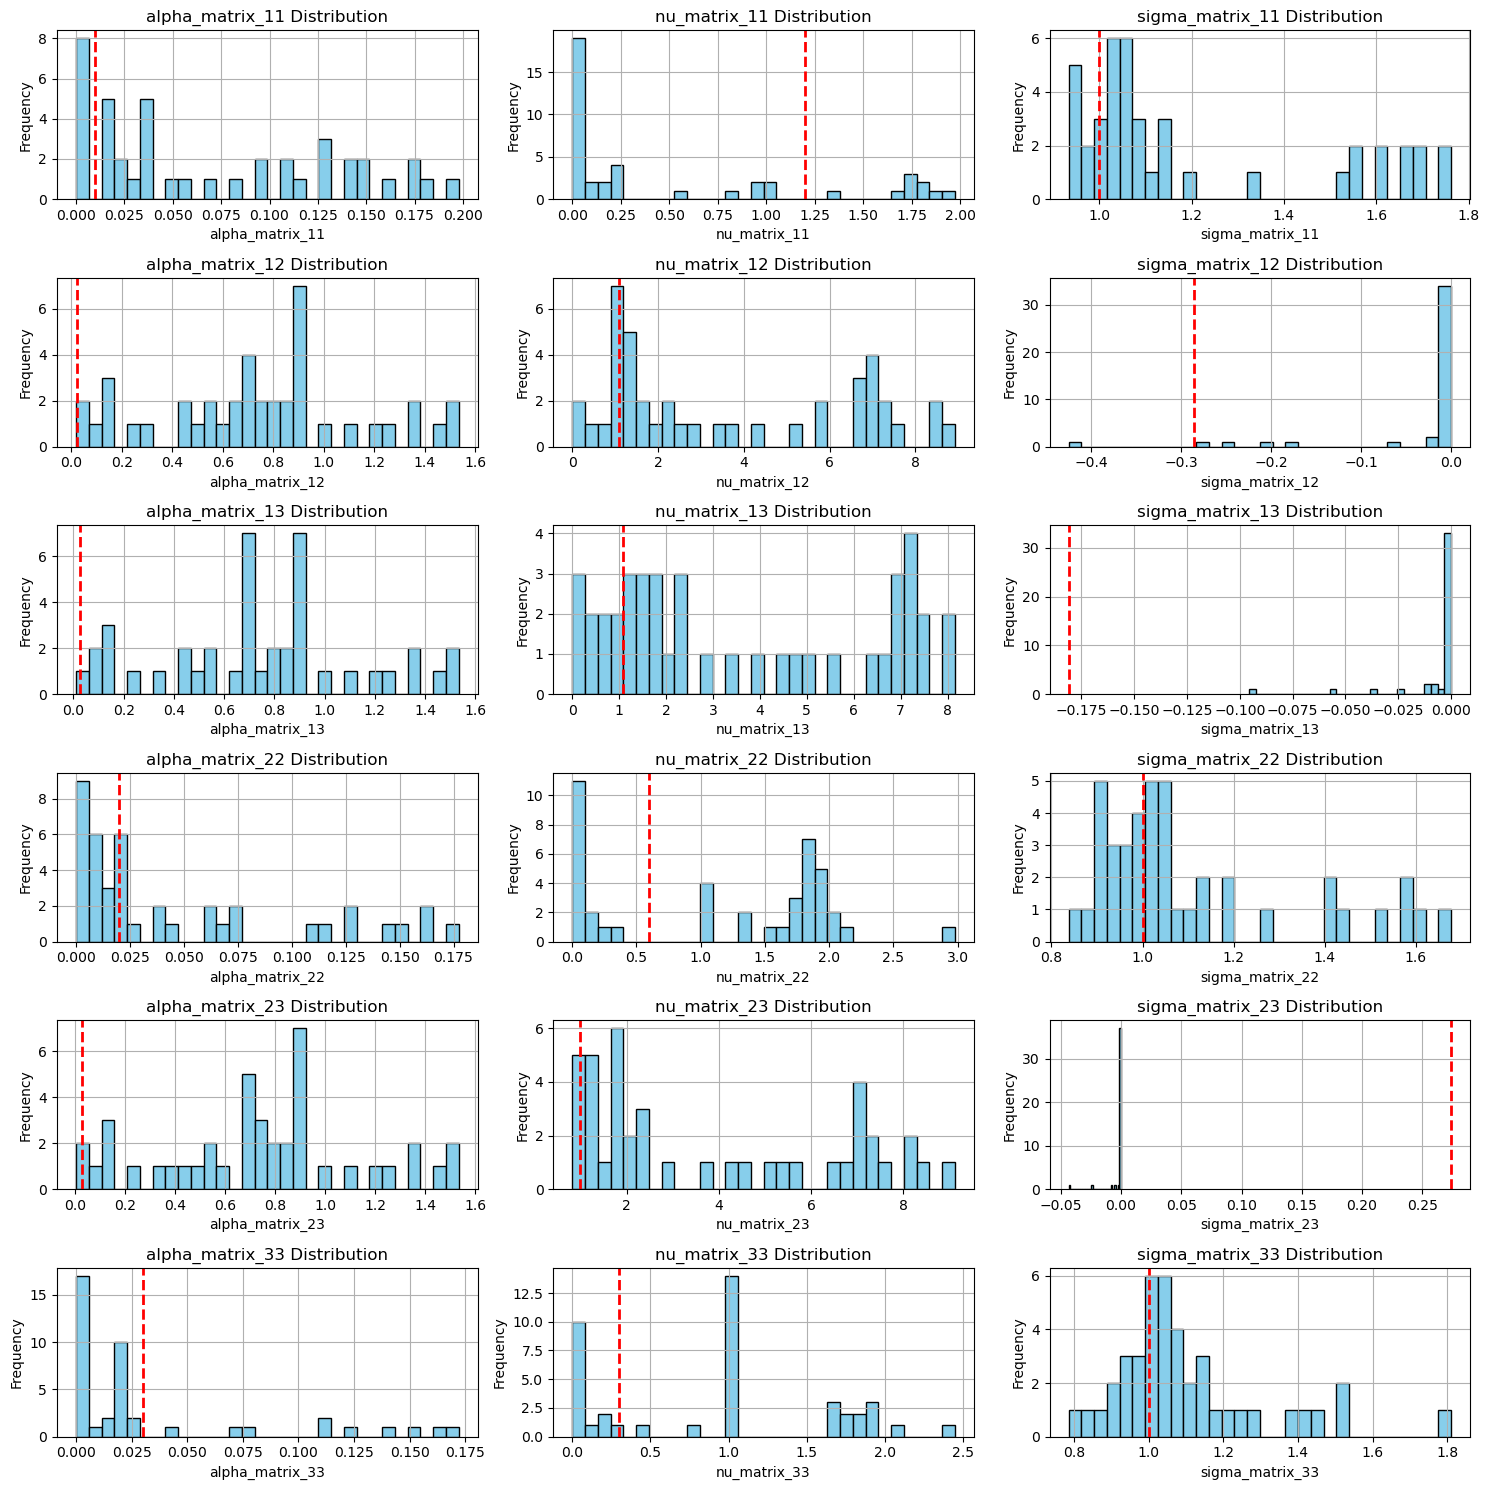

In [15]:
import matplotlib.pyplot as plt
import math

# Get the list of columns
columns = estimated_params_df.columns

# Calculate the number of rows and columns for subplots
n_params = len(columns)
n_cols = 3  # Fixed number of columns for layout
n_rows = math.ceil(n_params / n_cols)  # Calculate required rows based on the number of parameters

plt.figure(figsize=(15, 2.5 * n_rows))  # Adjust height based on number of rows
for i, col in enumerate(columns):
    plt.subplot(n_rows, n_cols, i + 1)
    
    # Plot the histogram of estimates
    plt.hist(estimated_params_df[col], bins=30, color='skyblue', edgecolor='black')
    
    # Plot the vertical line for the true value
    plt.axvline(x=ground_truth_df[col].iloc[0], color='red', linestyle='--', linewidth=2)
    
    plt.title(f'{col} Distribution')
    plt.xlabel(f'{col}')
    plt.ylabel('Frequency')
    plt.grid(True)

plt.tight_layout()
plt.show()

(array([ 1.,  2.,  7., 12.,  3.,  6.,  6.,  2.,  2.,  1.]),
 array([0.26672777, 0.30675755, 0.34678733, 0.3868171 , 0.42684688,
        0.46687666, 0.50690644, 0.54693622, 0.586966  , 0.62699578,
        0.66702555]),
 <BarContainer object of 10 artists>)

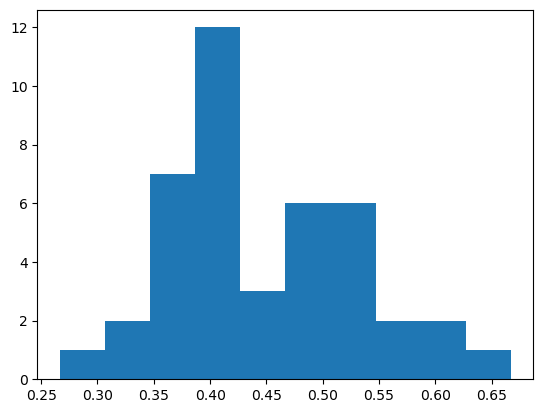

In [16]:
plt.hist(distance_K_df[0])

In [17]:
distance_K_df

,0
0,0.476620
1,0.407932
2,0.345248
3,0.375844
4,0.543789
5,0.389006
6,0.379372
7,0.472623
8,0.266728
9,0.495937


In [18]:
# Example usage
Delta_A = torch.tensor(0.5, dtype=torch.float64, requires_grad=True)
Delta_B = torch.tensor(0.5, dtype=torch.float64, requires_grad=True)
rho_A = torch.tensor(0.5, dtype=torch.float64, requires_grad=True)
rho_B = torch.tensor(0.5, dtype=torch.float64, requires_grad=True)
rho_V = torch.tensor(0.8, dtype=torch.float64, requires_grad=True)


W = torch.tensor([1.0, 2.0, 3.0], dtype=torch.float64, requires_grad=True)
alpha = torch.tensor([0.2, 0.3, 0.4], dtype=torch.float64, requires_grad=True)
nu = torch.tensor([0.5, 0.6, 0.7], dtype=torch.float64, requires_grad=True)
sigma = torch.tensor([0.1, 0.2 , 0.3], dtype=torch.float64, requires_grad=True)
compute_parameter_matrices(Delta_A, Delta_B, rho_A, rho_B, rho_V, W, alpha, nu, sigma)

(tensor([[0.2000, 0.5612, 0.5916],
         [0.5612, 0.3000, 0.6124],
         [0.5916, 0.6124, 0.4000]], dtype=torch.float64, grad_fn=<AddBackward0>),
 tensor([[0.5000, 0.8000, 0.8500],
         [0.8000, 0.6000, 0.9000],
         [0.8500, 0.9000, 0.7000]], dtype=torch.float64, grad_fn=<AddBackward0>),
 tensor([[ 0.1000,  5.9792,  8.0061],
         [ 5.9792,  0.2000, 14.8307],
         [ 8.0061, 14.8307,  0.3000]], dtype=torch.float64,
        grad_fn=<AddBackward0>))